In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# Load Dataset

housing = fetch_california_housing(as_frame=True)

df = pd.concat(
    [housing.data, housing.target.rename("HouseValue")],
    axis=1
)

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HouseValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
print(df.shape)

print(df.columns)

print(df.isnull().sum())

(20640, 9)
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'HouseValue'],
      dtype='object')
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
HouseValue    0
dtype: int64


In [4]:
print(df.describe())

             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude    HouseValue  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        0.692308     32.54000

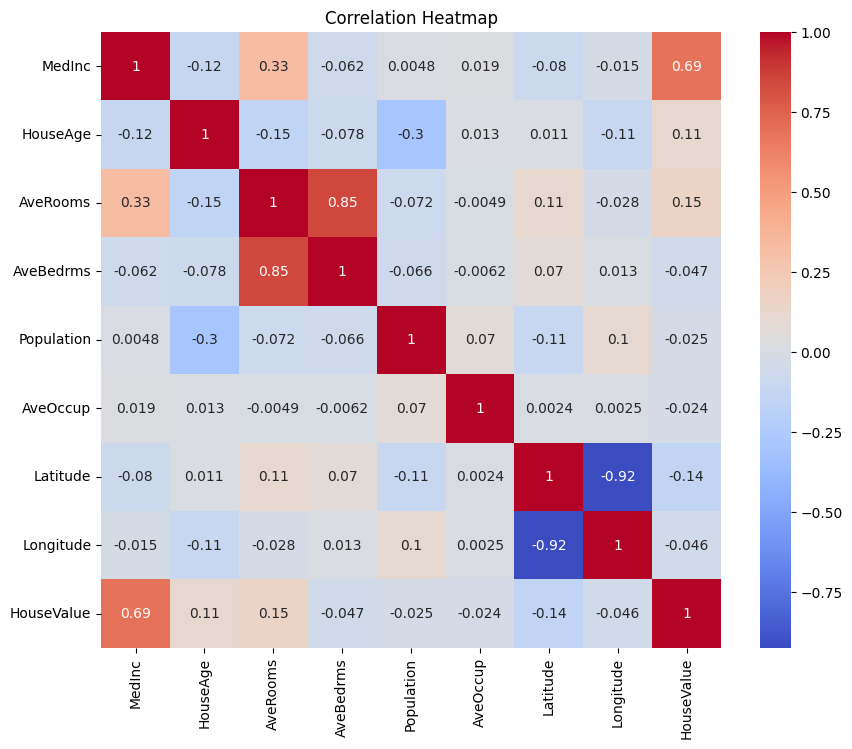

In [5]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

In [7]:
X = df.drop("HouseValue", axis=1)

y = df["HouseValue"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [10]:
y_pred = model.predict(X_test)

In [11]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)

print("RMSE:", rmse)

print("R2 Score:", r2)

MAE: 0.5332001304956553
RMSE: 0.7455813830127764
R2 Score: 0.5757877060324508


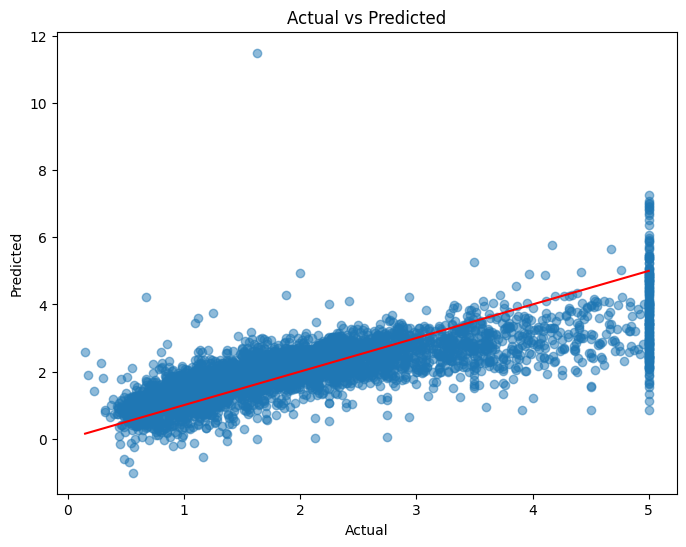

In [12]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.plot(
    [min(y_test), max(y_test)],
    [min(y_test), max(y_test)],
    color='red'
)

plt.show()

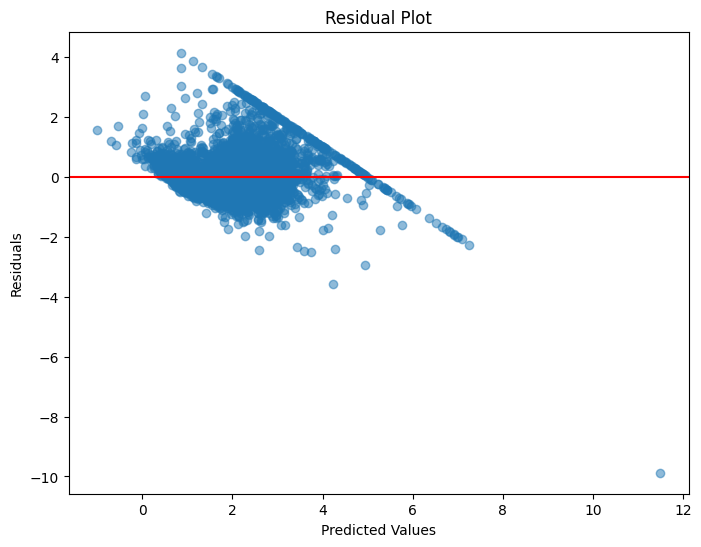

In [13]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals, alpha=0.5)

plt.axhline(y=0, color='red')

plt.xlabel("Predicted Values")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()